# Ngày 4 - Từ 17 cái chấm của bạn đến một model pose

Notebook này chạy **sau** khi nhãn của bạn đã qua cổng gold (`tools/evaluate_pose_annotations.py`).
Trình tự: kiểm nhãn -> đo model gốc -> fine-tune trên nhãn của bạn -> đo lại -> nhìn tận mắt.

## Hợp đồng chạy

- Chạy local: dùng repo hiện tại đã clone; cell 0 tự tìm thư mục gốc, không clone thêm.
- Chạy Colab: upload/mount repo đã chuẩn bị rồi đặt `LAB_ROOT_OVERRIDE` ở cell 0.
- **Không** upload protected reference. Nếu bạn có `gold/`, nó cũng không được dùng để train.
- Chạy từ trên xuống. Không đổi `val` trong `data.yaml` sang tập train để làm đẹp số.
- 20 ảnh là quá ít để ra một model dùng được. Cái bạn đo hôm nay là **vòng lặp dữ liệu**,
  không phải chất lượng sản phẩm. Con số quan trọng là *chênh lệch* giữa trước và sau fine-tune.


## 0. Dùng repo hiện tại

Chạy từ thư mục gốc hoặc `notebooks/`: cell dưới tự tìm repo chứa notebook, không chạy `git clone`.
Nếu chạy từ nơi khác hoặc trên Colab, đặt `LAB_ROOT_OVERRIDE` thành đường dẫn repo đã upload/mount.
Sau khi đổi cấu trúc thư mục, restart kernel rồi chạy lại từ cell này để bỏ các đường dẫn cũ trong bộ nhớ.
Các output train/đánh giá đã lưu phía dưới là kết quả lịch sử, có thể còn hiển thị đường dẫn cũ.


In [14]:
import subprocess
from pathlib import Path

# Để trống khi chạy trong repo. Với Colab, nhập đường dẫn repo đã upload/mount.
LAB_ROOT_OVERRIDE = ""

def find_lab_root(start, override=""):
    def is_lab(path):
        return ((path / 'data.yaml').is_file()
                and (path / 'tools/check_pose_labels.py').is_file()
                and (path / 'dataset/images/train').is_dir())

    if override.strip():
        root = Path(override).expanduser().resolve()
        if not is_lab(root):
            raise FileNotFoundError(f'Đường dẫn không phải repo bài lab: {root}')
        return root

    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if is_lab(candidate):
            return candidate
    raise FileNotFoundError(
        'Không tìm thấy repo bài lab. Mở notebook trong repo đã clone, '
        'hoặc đặt LAB_ROOT_OVERRIDE tới repo đã upload/mount. Không tự clone thêm.'
    )

LAB_ROOT = find_lab_root(Path.cwd(), LAB_ROOT_OVERRIDE)
print('Dùng repo hiện tại:', LAB_ROOT)


Dùng repo hiện tại: /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268


In [15]:
%pip -q install -U ultralytics

import json
import sys
from pathlib import Path

import torch
import yaml
from ultralytics import YOLO

# Luôn giải quyết lại đường dẫn, không dùng LAB_ROOT cũ từ phiên chạy trước.
if 'find_lab_root' not in globals():
    raise RuntimeError('Hãy chạy cell 0 để xác định repo hiện tại trước.')
LAB_ROOT = find_lab_root(Path.cwd(), LAB_ROOT_OVERRIDE)

TRAIN_IMAGES = LAB_ROOT / 'dataset/images/train'
TRAIN_LABELS = LAB_ROOT / 'dataset/labels/train'
TEST_IMAGES = LAB_ROOT / 'dataset/images/test'
TEST_LABELS = LAB_ROOT / 'dataset/labels/test'
OUTPUTS = LAB_ROOT / 'outputs'
RUNS = OUTPUTS / 'runs'
OUTPUTS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(LAB_ROOT / 'tools'))

# Sinh data_colab.yaml trỏ 'path' vào đúng nơi vừa upload. File data.yaml gốc
# trong repo giữ nguyên, nên bạn commit lại mà không bị lệch đường dẫn.
config = yaml.safe_load((LAB_ROOT / 'data.yaml').read_text())
config['path'] = str(LAB_ROOT)
DATA_YAML = LAB_ROOT / 'data_colab.yaml'
DATA_YAML.write_text(yaml.safe_dump(config, sort_keys=False, allow_unicode=True))

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'yolo26n-pose.pt'   # đổi sang 'yolo11n-pose.pt' nếu muốn so hai thế hệ
print('LAB_ROOT :', LAB_ROOT)
print('device   :', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE == 0 else 'CPU - sẽ chậm')
print('kpt_shape:', config['kpt_shape'], '| flip_idx:', config['flip_idx'])
assert config['kpt_shape'] == [17, 3], 'kpt_shape phải là [17, 3], nếu không cờ visibility đã bị vứt'


Note: you may need to restart the kernel to use updated packages.
LAB_ROOT : /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268
device   : 0 | NVIDIA RTX A1000 Laptop GPU
kpt_shape: [17, 3] | flip_idx: [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]


## 1. Kiểm nhãn trước khi train

Chạy đúng script bạn đã chạy ở local: 56 số một dòng, cờ chỉ nhận 0/1/2, đủ file cho từng ảnh.
Một file nhãn hỏng ở đây sẽ thành một model hỏng ở dưới, mà không có dòng cảnh báo nào.


In [16]:
coco_relative_path = Path('annotations/coco_keypoints/person_keypoints_default.json')
coco_candidates = (
    LAB_ROOT / coco_relative_path,
    Path.cwd() / coco_relative_path,
    Path.cwd().parent / coco_relative_path,
    Path.cwd().parent.parent / coco_relative_path,
)
coco_path = next((path for path in coco_candidates if path.is_file()), None)
if coco_path is None:
    raise FileNotFoundError(f'Không thấy file COCO: {coco_relative_path}')

conversion = subprocess.run(
    [sys.executable, str(LAB_ROOT / 'tools/coco_kp_to_yolo_pose.py'),
     '--coco', str(coco_path),
     '--out', str(TRAIN_LABELS)],
    capture_output=True, text=True)
print(conversion.stdout or conversion.stderr)
conversion.check_returncode()

Đã ghi 20 file nhãn vào /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/labels/train (28 skeleton).
Chạy tiếp: python3 tools/check_pose_labels.py



In [17]:
VIS_OUT = OUTPUTS / "vis_train"
VIS_OUT.mkdir(parents=True, exist_ok=True)

visualizer = LAB_ROOT / "tools/visualize_pose.py"
assert visualizer.is_file(), f"Không tìm thấy: {visualizer}"
assert TRAIN_IMAGES.is_dir(), f"Không tìm thấy thư mục ảnh: {TRAIN_IMAGES}"
assert TRAIN_LABELS.is_dir(), f"Không tìm thấy thư mục nhãn: {TRAIN_LABELS}"

result = subprocess.run(
    [
        sys.executable,
        str(visualizer),
        "--images", str(TRAIN_IMAGES),
        "--labels", str(TRAIN_LABELS),
        "--out", str(VIS_OUT),
    ],
    capture_output=True,
    text=True,
)

if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)

result.check_returncode()
print(f"Đã ghi ảnh trực quan vào: {VIS_OUT}")

Đã vẽ 28 skeleton vào /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/outputs/vis_train
Xanh = bên trái cơ thể, cam = bên phải, vàng = khớp bị che (v=1).
Nhìn vùng vai và hông: hai đường nối cắt chéo nhau => nghi đảo trái/phải.

Đã ghi ảnh trực quan vào: /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/outputs/vis_train


In [18]:
check_result = subprocess.run(
    [
        sys.executable,
        str(LAB_ROOT / "tools/check_pose_labels.py"),
        "--images", str(TRAIN_IMAGES),
        "--labels", str(TRAIN_LABELS),
    ],
    capture_output=True,
    text=True,
)

print(check_result.stdout or check_result.stderr)
check_result.check_returncode()

report_result = subprocess.run(
    [
        sys.executable,
        str(LAB_ROOT / "tools/visibility_report.py"),
        "--labels", str(TRAIN_LABELS),
        "--out", str(OUTPUTS / "visibility_report.json"),
        "--markdown", str(LAB_ROOT / "reports/visibility_report.md"),
    ],
    capture_output=True,
    text=True,
)

print(report_result.stdout or report_result.stderr)
report_result.check_returncode()

print(check_result.stdout or check_result.stderr)
check_result.check_returncode()

(OUTPUTS / "visibility_report.json").parent.mkdir(parents=True, exist_ok=True)
(OUTPUTS.parent / "reports").mkdir(parents=True, exist_ok=True)

report_result = subprocess.run(
    [
        sys.executable,
        str(LAB_ROOT / "tools/visibility_report.py"),
        "--labels", str(TRAIN_LABELS),
        "--out", str(OUTPUTS / "visibility_report.json"),
        "--markdown", str(OUTPUTS.parent / "reports/visibility_report.md"),
    ],
    capture_output=True,
    text=True,
)

print(report_result.stdout or report_result.stderr)
report_result.check_returncode()

Đã đọc 20/20 file nhãn, 28 skeleton.
Cờ visibility: v=2 361 | v=1 88 | v=0 27

CẢNH BÁO (8) - không chặn nộp, nhưng phải xem lại:
- train_02.txt:1: left_shoulder/right_shoulder nằm ngược chiều so với hai mắt - dấu hiệu đảo trái/phải, mở tools/visualize_pose.py xem lại
- train_02.txt:1: left_hip/right_hip nằm ngược chiều so với hai mắt - dấu hiệu đảo trái/phải, mở tools/visualize_pose.py xem lại
- train_04.txt:1: có 4 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_04.txt:2: có 5 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_10.txt:1: có 4 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_11.txt:1: có 4 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), k

In [19]:
gold_candidates = (
    LAB_ROOT / 'gold/labels/train',
    LAB_ROOT.parent / 'gold/labels/train',
    LAB_ROOT.parent.parent / 'gold/labels/train',
    Path.cwd() / 'gold/labels/train',
    Path.cwd().parent / 'gold/labels/train',
    Path.cwd().parent.parent / 'gold/labels/train',
)

gold_labels = next((path for path in gold_candidates if path.is_dir()), None)
if gold_labels is None:
    print(
        'Bỏ qua đối chiếu gold: không tìm thấy gold/labels/train. '
        'Gold là dữ liệu protected và không được upload vào repo.'
    )
else:
    evaluator = LAB_ROOT / 'tools/evaluate_pose_annotations.py'
    eval_output = OUTPUTS / 'eval_vs_gold.json'

    evaluation = subprocess.run(
        [
            sys.executable,
            str(evaluator),
            '--pred', str(TRAIN_LABELS),
            '--gold', str(gold_labels),
            '--images', str(TRAIN_IMAGES),
            '--out', str(eval_output),
        ],
        capture_output=True,
        text=True,
    )

    print(evaluation.stdout or evaluation.stderr)
    evaluation.check_returncode()
    print(f'Đã ghi kết quả vào: {eval_output}')

OKS trung bình : 0.916
OKS@0.50       : 0.966  (tỉ lệ người gán đúng ở mức 'nhận ra pose')
OKS@0.75       : 0.966  (tỉ lệ người gán đủ chính xác để train)
Người: gold 29 | ghép được 28 | thiếu 1 | thừa 0
Mức            : Xuất sắc

Danh sách lỗi theo loại:
-    2  Nhầm người - chấm rơi sang cơ thể bên cạnh
-    1  Thiếu hẳn một người
-   10  Lệch nhẹ - sửa được, ít hại
-   56  Cờ khác gold (vị trí vẫn đúng) - không trừ điểm OKS
-   68  Gold để v=0 ở khớp bạn có gán - không trừ điểm

3 skeleton cần sửa trước:
- train_13.jpg người #1: OKS 0.000 -> Thiếu hẳn một người
- train_03.jpg người #1: OKS 0.863 -> Nhầm người(right_hip)
- train_04.jpg người #1: OKS 0.866 -> Nhầm người(left_wrist)

Chi tiết từng khớp: /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/outputs/eval_vs_gold.json
Vẽ lại bằng tools/visualize_pose.py rồi sửa, sau đó chạy lại script này. Rework không bị trừ điểm.

Đã ghi kết quả vào: /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/outputs/eval_vs_gold.json


In [20]:
import subprocess

result = subprocess.run(
    [sys.executable, str(LAB_ROOT / 'tools/check_pose_labels.py'),
     '--images', str(TRAIN_IMAGES), '--labels', str(TRAIN_LABELS)],
    capture_output=True, text=True)
print(result.stdout or result.stderr)
assert result.returncode == 0, 'Nhãn train chưa đạt định dạng - sửa trước khi train'

from poselib import parse_yolo_pose_file

def count(label_dir):
    files = sorted(label_dir.glob('*.txt'))
    people = [p for f in files for p in parse_yolo_pose_file(f)]
    flags = [v for p in people for _, _, v in p.keypoints]
    return len(files), len(people), flags.count(2), flags.count(1), flags.count(0)

for name, directory in (('train (nhãn của bạn)', TRAIN_LABELS), ('test  (nhãn phát sẵn)', TEST_LABELS)):
    files, people, v2, v1, v0 = count(directory)
    print(f'{name}: {files} file, {people} skeleton, v=2 {v2}, v=1 {v1}, v=0 {v0}')


Đã đọc 20/20 file nhãn, 28 skeleton.
Cờ visibility: v=2 361 | v=1 88 | v=0 27

CẢNH BÁO (8) - không chặn nộp, nhưng phải xem lại:
- train_02.txt:1: left_shoulder/right_shoulder nằm ngược chiều so với hai mắt - dấu hiệu đảo trái/phải, mở tools/visualize_pose.py xem lại
- train_02.txt:1: left_hip/right_hip nằm ngược chiều so với hai mắt - dấu hiệu đảo trái/phải, mở tools/visualize_pose.py xem lại
- train_04.txt:1: có 4 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_04.txt:2: có 5 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_10.txt:1: có 4 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), không phải v=0
- train_11.txt:1: có 4 khớp v=0 trong khi cả người nằm gọn giữa ảnh. Khớp không ra khỏi khung được thì phải là v=1 (bị che, vẫn đặt chấm), k

## 2. Model gốc, chưa học gì từ nhãn của bạn

`yolo26n-pose.pt` đã được train sẵn trên COCO - tức là nó **đã biết** bộ 17 điểm này.
Đo nó trên tập test trước, để lát nữa có mốc mà so. Đây là baseline, không phải đối thủ.


In [21]:
baseline_model = YOLO(MODEL_NAME)
baseline_metrics = baseline_model.val(
    data=str(DATA_YAML), split='val', device=DEVICE, plots=False,
    project=str(RUNS), name='baseline', exist_ok=True)

def summarize(metrics):
    return {
        'pose_mAP50': round(float(metrics.pose.map50), 4),
        'pose_mAP50_95': round(float(metrics.pose.map), 4),
        'pose_precision': round(float(metrics.pose.mp), 4),
        'pose_recall': round(float(metrics.pose.mr), 4),
        'box_mAP50': round(float(metrics.box.map50), 4),
        'box_mAP50_95': round(float(metrics.box.map), 4),
    }

baseline = summarize(baseline_metrics)
print(json.dumps(baseline, indent=2))


Ultralytics 8.4.153 🚀 Python-3.12.3 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A1000 Laptop GPU, 3768MiB)
YOLO26n-pose summary (fused): 129 layers, 2,926,494 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 648.5±305.4 MB/s, size: 79.3 KB)
val: Scanning /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/labels/test... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 446.0it/s 0.0s
val: New cache created: /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.8it/s 0.2s
                   all         10         13      0.995      0.923      0.979      0.805      0.973      0.846      0.845      0.685
Speed: 0.6ms preprocess, 6.7ms inference, 0.0ms loss, 1.3ms postprocess per image
{
  "pose_mAP50": 0.845,
  "pose_mAP50_95": 0.6853,
  "pose_precision": 0

## 3. Fine-tune trên nhãn của bạn

`fliplr=0.5` là augmentation lật ảnh ngang. Ultralytics đọc `flip_idx` trong `data.yaml`
để đổi tên khớp trái/phải cho ảnh lật. Đây chính là slide 15: nếu nhãn của bạn đảo trái/phải,
model được dạy cái sai đó **hai lần** - một lần ở ảnh gốc, một lần ở ảnh lật.

Muốn thấy tận mắt: chạy lại cell này với `fliplr=0.0` và so `pose_mAP50-95`.


In [22]:
model = YOLO(MODEL_NAME)
train_result = model.train(
    data=str(DATA_YAML),
    epochs=80,
    imgsz=640,
    batch=8,
    device=DEVICE,
    workers=2,
    project=str(RUNS),
    name='pose_finetune',
    exist_ok=True,
    seed=20260915,
    fliplr=0.5,
    plots=True,
    patience=30,
)
BEST = Path(model.trainer.best)
print('checkpoint tốt nhất:', BEST)


Ultralytics 8.4.153 🚀 Python-3.12.3 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A1000 Laptop GPU, 3768MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/data_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_sc

## 4. Đánh giá trên đúng tập test

`data.yaml` trỏ `val` tới 10 ảnh test đã có nhãn phát sẵn. Không đổi nó sang train.

`pose_mAP` chấm bằng **OKS** - đúng thước đo bạn đã dùng để chấm nhãn của mình ở
`tools/evaluate_pose_annotations.py`. Cùng một công thức, một bên đo người, một bên đo model.


In [23]:
best_model = YOLO(str(BEST))
finetuned_metrics = best_model.val(
    data=str(DATA_YAML), split='val', device=DEVICE, plots=True,
    project=str(RUNS), name='pose_eval', exist_ok=True)
finetuned = summarize(finetuned_metrics)

comparison = {'baseline_' + MODEL_NAME.replace('.pt', ''): baseline, 'finetuned': finetuned,
              'delta': {k: round(finetuned[k] - baseline[k], 4) for k in baseline}}
(OUTPUTS / 'eval_model.json').write_text(json.dumps(comparison, ensure_ascii=False, indent=2))

header = f"{'chỉ số':<16}{'gốc':>10}{'sau fine-tune':>16}{'chênh':>10}"
print(header); print('-' * len(header))
for key in baseline:
    print(f'{key:<16}{baseline[key]:>10.4f}{finetuned[key]:>16.4f}{comparison["delta"][key]:>+10.4f}')
print('\nĐã ghi outputs/eval_model.json')


Ultralytics 8.4.153 🚀 Python-3.12.3 torch-2.14.0+cu130 CUDA:0 (NVIDIA RTX A1000 Laptop GPU, 3768MiB)
YOLO26n-pose summary (fused): 129 layers, 2,926,494 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1178.5±329.4 MB/s, size: 95.7 KB)
val: Scanning /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/labels/test.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 1.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.6it/s 0.3s
                   all         10         13      0.995      0.923      0.979      0.808      0.977      0.846      0.845      0.714
Speed: 0.6ms preprocess, 6.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/outputs/runs/pose_eval
chỉ số                 gốc   sau fine-tune     chênh
------------------------

## 5. Nhìn tận mắt - 10 ảnh test kèm pose model đoán

Con số ở trên không nói cho bạn biết model sai **kiểu gì**. Bốn kiểu sai của slide 43
(lệch nhẹ / đảo trái/phải / nhầm người / trượt hẳn) áp cho model y như áp cho người.



image 1/10 /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/images/test/test_01.jpg: 640x576 1 person, 26.7ms
image 2/10 /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/images/test/test_02.jpg: 448x640 2 persons, 32.4ms
image 3/10 /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/images/test/test_03.jpg: 448x640 2 persons, 26.2ms
image 4/10 /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/images/test/test_04.jpg: 480x640 1 person, 37.4ms
image 5/10 /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/images/test/test_05.jpg: 640x448 1 person, 38.2ms
image 6/10 /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/images/test/test_06.jpg: 576x640 2 persons, 31.9ms
image 7/10 /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/images/test/test_07.jpg: 608x640 1 person, 32.7ms
image 8/10 /home/peter/Documents/Day4-NguyenMinhQuan-2A202602268/dataset/images/test/test_08.jpg: 352x640 1 person, 27.1ms
image 9/10 /

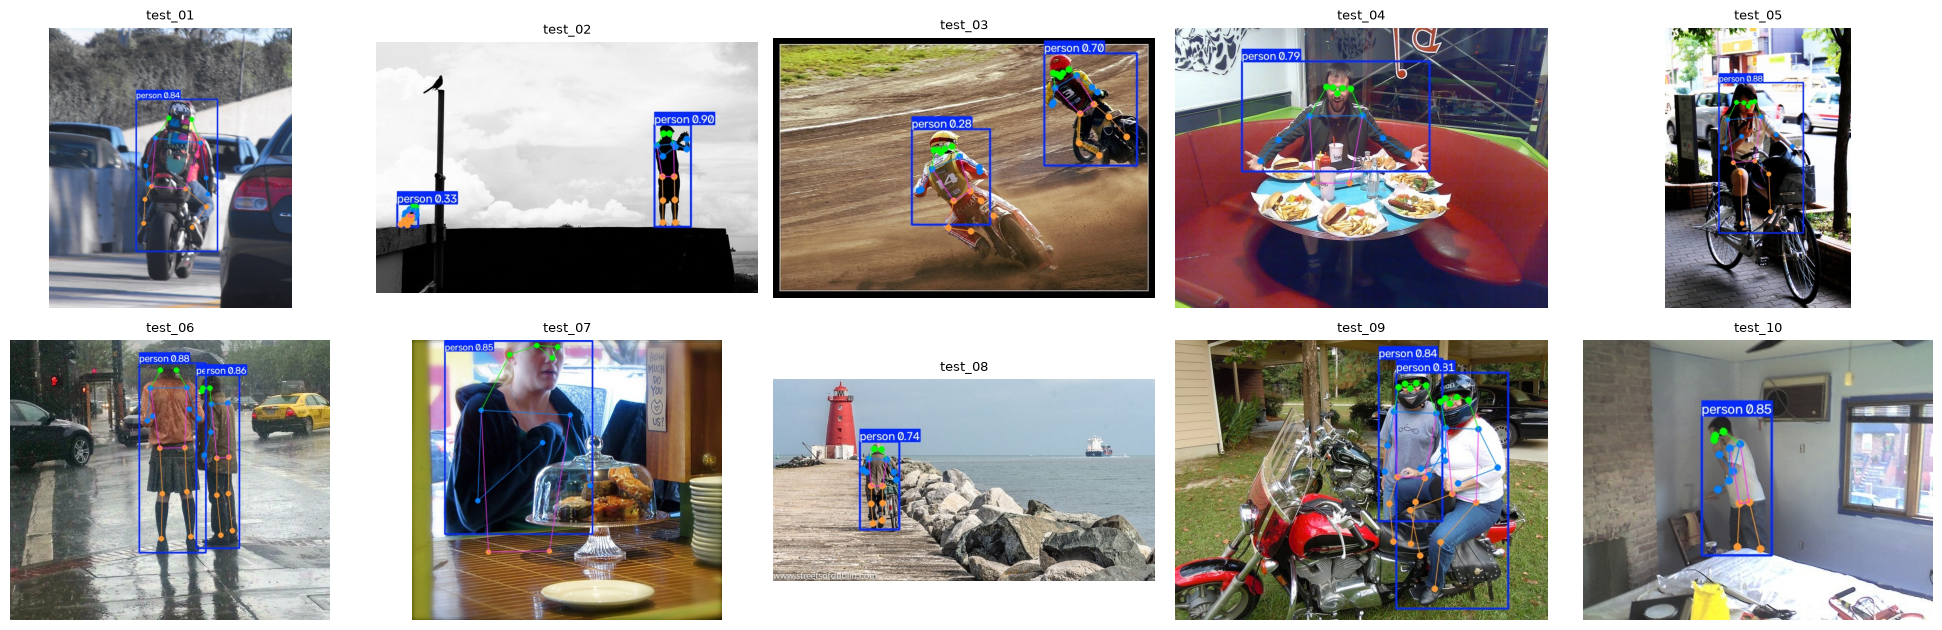

In [24]:
import math

import matplotlib.pyplot as plt
from PIL import Image

PRED_DIR = RUNS / 'predictions'
best_model.predict(source=str(TEST_IMAGES), conf=0.25, device=DEVICE, save=True,
                   project=str(PRED_DIR), name='test', exist_ok=True)
predicted = sorted((PRED_DIR / 'test').glob('*.jpg'))

columns = 5
rows = math.ceil(len(predicted) / columns)
figure, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3.2 * rows))
for axis, path in zip(axes.flat, predicted):
    axis.imshow(Image.open(path)); axis.set_title(path.stem, fontsize=9)
for axis in axes.flat:
    axis.axis('off')
plt.tight_layout(); plt.show()


## 6. Nhãn của bạn vs model chấm thử, trên chính tập train

Slide 27: model chấm thử **một lần để đối chiếu, không phải đáp án**. Bạn đã tự gán xong
và đã qua cổng gold rồi, nên bây giờ mới được nhìn.

Chỗ nào model và bạn lệch nhau nhiều: hoặc model sai (ảnh khó), hoặc nhãn của bạn sai
(và gold đã chỉ ra rồi). Ghi lại 2-3 ca vào báo cáo.


In [25]:
from poselib import Person, greedy_match, image_size

OUT_OF_FRAME = 0
rows_out = []
for image_path in sorted(TRAIN_IMAGES.glob('*.jpg')):
    width, height = image_size(image_path)
    mine = parse_yolo_pose_file(TRAIN_LABELS / f'{image_path.stem}.txt')
    prediction = best_model.predict(source=str(image_path), conf=0.25, device=DEVICE, verbose=False)[0]
    theirs = []
    for box, keypoints in zip(prediction.boxes.xywhn.tolist(), prediction.keypoints.data.tolist()):
        points = [(x / width, y / height, 2 if score >= 0.5 else 1) if score > 0.05 else (0.0, 0.0, OUT_OF_FRAME)
                  for x, y, score in keypoints]
        theirs.append(Person(tuple(box), points))
    matched, extra, missed = greedy_match(theirs, mine, width, height)
    for _, _, score in matched:
        rows_out.append((image_path.stem, round(score, 3)))
    if extra or missed:
        rows_out.append((image_path.stem + ' (số người lệch)', f'model {len(theirs)} / bạn {len(mine)}'))

print(f"{'ảnh':<28}{'OKS model vs nhãn của bạn':>28}")
for stem, value in sorted(rows_out, key=lambda r: (isinstance(r[1], str), r[1])):
    print(f'{stem:<28}{value:>28}')
print('\nOKS thấp = model và bạn bất đồng. Xem lại ảnh đó bằng tools/visualize_pose.py.')


ảnh                            OKS model vs nhãn của bạn
train_06                                           0.669
train_15                                           0.671
train_09                                           0.677
train_14                                           0.679
train_14                                           0.703
train_13                                           0.706
train_12                                           0.724
train_02                                           0.726
train_03                                           0.738
train_19                                           0.742
train_11                                           0.743
train_01                                           0.766
train_10                                            0.77
train_04                                           0.808
train_16                                           0.811
train_01                                           0.824
train_16                       

## Câu hỏi phân tích để nộp

Trả lời trong `reports/REPORT.md`:

1. `pose_mAP50-95` thay đổi bao nhiêu sau fine-tune? Nếu nó **giảm**, hãy giải thích:
   20 ảnh của bạn dạy được model điều gì mà COCO chưa dạy, và nó làm hỏng điều gì?
2. `box_mAP` và `pose_mAP` chênh nhau bao nhiêu? Model tìm *người* dễ hơn hay tìm *khớp* dễ hơn?
3. Ở mục 5, tìm một ảnh model đoán sai. Gọi tên lỗi theo bốn loại của slide 43.
4. Ở mục 6, ảnh nào có OKS thấp nhất giữa bạn và model? Ai đúng - và bạn dựa vào đâu để nói vậy?
5. Trong `tools/evaluate_pose_annotations.py` bạn đã có OKS nhãn-của-bạn vs gold.
   Ảnh nào bạn gán tệ nhất *cũng* là ảnh model đoán tệ nhất? Nếu có, điều đó nói gì về ảnh đó?
